# S&P 500 动量因子选股

**目标**: 用纯量价动量特征 + LightGBM 在 S&P 500 中预测未来 10 天残差收益率，选出 top 30 股票等权持有。

**Pipeline**: 数据下载 → 特征工程（~50 个量价特征）→ 标签构造（10 天残差收益）→ LightGBM + Purged CV → 回测 → 分析

**已知偏差**:
- 使用当前 S&P 500 成分股，存在 **survivorship bias**（存活者偏差）
- 残差收益用 `r_stock - r_SPY` 近似，理论上应用 beta-adjusted 残差 `r_i - β_i × r_m`

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from equity.data import get_sp500_tickers, download_stock_data, load_universe, load_spy
from equity.features import compute_all_features, cross_sectional_rank
from equity.labels import make_labels, rank_labels
from equity.model import run_cv_pipeline
from equity.backtest import backtest_topN, compute_daily_returns
from equity.analysis import (
    summary_metrics, print_metrics,
    calc_ic_series, quantile_analysis,
    plot_equity_curve, plot_ic_analysis, plot_quantile_returns, plot_feature_importance,
)

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. 数据下载

下载 S&P 500 全部成分股 + SPY 的日线 OHLCV（2015-2026）。首次运行需要几分钟，之后从 parquet 缓存加载。

In [2]:
tickers = get_sp500_tickers()
print(f"S&P 500 tickers: {len(tickers)}")
print(f"Sample: {tickers[:10]}")

download_stock_data(tickers, start="2015-01-01", end="2026-04-01", cache_dir="../data/equity")

S&P 500 tickers: 503
Sample: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']
All 504 tickers already cached.


In [3]:
# 加载数据
panel = load_universe(cache_dir="../data/equity", min_history_days=252)
spy = load_spy(cache_dir="../data/equity")

n_stocks = panel.index.get_level_values("ticker").nunique()
date_range = panel.index.get_level_values("date")
print(f"Universe: {n_stocks} stocks")
print(f"Date range: {date_range.min().date()} to {date_range.max().date()}")
print(f"Total rows: {len(panel):,}")
print(f"\nSPY: {len(spy)} days")
print(f"\nSample:")
panel.head()

Universe: 502 stocks
Date range: 2015-01-02 to 2026-03-31
Total rows: 1,375,458

SPY: 2827 days

Sample:


Price                   open       high        low      close       volume
date       ticker                                                         
2015-01-02 A       37.535488  37.653983  36.797173  36.970360    1529200.0
           AAPL    24.671145  24.682220  23.776348  24.214888  212818400.0
           ABBV    41.470293  42.078659  41.470293  41.755463    5086100.0
           ABT     36.517570  36.678974  36.025289  36.235115    3216600.0
           ACGL    18.764398  18.884845  18.472788  18.539352    1101600.0

## 2. 特征工程

计算 ~50 个量价动量特征，然后转截面百分位排名。

In [4]:
%%time
raw_features = compute_all_features(panel)
print(f"Raw features shape: {raw_features.shape}")
print(f"Feature columns ({len(raw_features.columns)}):")
print(raw_features.columns.tolist())

Raw features shape: (1375458, 36)
Feature columns (36):
['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ret_120d', 'ma_dev_5d', 'ma_dev_10d', 'ma_dev_20d', 'ma_dev_60d', 'ma_dev_120d', 'dist_52w_high', 'dist_52w_low', 'mom_accel_5_20', 'mom_accel_20_60', 'mom_accel_60_120', 'vol_ratio_5d', 'vol_ratio_10d', 'vol_ratio_20d', 'vol_trend_5_20', 'vol_trend_20_60', 'pv_divergence', 'rvol_5d', 'rvol_10d', 'rvol_20d', 'rvol_60d', 'vol_change_5_20', 'vol_change_5_60', 'intraday_range_5d', 'intraday_range_20d', 'atr_14d', 'atr_20d', 'rsi_5', 'rsi_14', 'macd_hist_norm', 'bb_pctb', 'channel_position']
CPU times: user 4.69 s, sys: 235 ms, total: 4.92 s
Wall time: 4.92 s


In [5]:
# 截面排名转换
features = cross_sectional_rank(raw_features)
print(f"Ranked features shape: {features.shape}")
print(f"Value range: [{features.min().min():.3f}, {features.max().max():.3f}]")
print(f"\nNaN ratio per feature:")
print((features.isna().sum() / len(features)).describe())

Ranked features shape: (1375458, 36)
Value range: [0.002, 1.000]

NaN ratio per feature:
count    36.000000
mean      0.017375
std       0.022234
min       0.001460
25%       0.004471
50%       0.007061
75%       0.021898
max       0.091607
dtype: float64


## 3. 标签构造

未来 10 天 **beta-adjusted** 残差收益率，再转截面排名。

**v0 → v1 改进**:
- v0 假设所有股票 β=1，对高β（科技~1.3）和低β（公用事业~0.5）股票引入系统性偏差
- v1 用滚动 252 天窗口估计每只股票的 β，残差 = r_stock - β × r_SPY
- 再做截面排名转换，将标签从绝对收益率（std~5.5%，信噪比极低）压缩为 [0,1] 均匀分布

In [6]:
%%time
# Beta-adjusted residual return labels
raw_labels = make_labels(panel, spy, periods=10, beta_window=252)
print(f"Raw labels shape: {raw_labels.shape}")
print(f"NaN ratio: {raw_labels.isna().mean():.3f}")
print(f"\nRaw label distribution:")
print(raw_labels.dropna().describe())

# Cross-sectional rank transformation
labels = rank_labels(raw_labels)
print(f"\nRanked labels distribution:")
print(labels.dropna().describe())

Raw labels shape: (1375458,)
NaN ratio: 0.050

Raw label distribution:
count    1.307186e+06
mean     9.836761e-04
std      5.424368e-02
min     -7.833699e-01
25%     -2.649492e-02
50%      3.064195e-04
75%      2.715335e-02
max      1.781302e+00
Name: label, dtype: float64

Ranked labels distribution:
count    1.307186e+06
mean     5.010293e-01
std      2.886746e-01
min      1.992032e-03
25%      2.510288e-01
50%      5.010183e-01
75%      7.510288e-01
max      1.000000e+00
Name: label, dtype: float64
CPU times: user 1.28 s, sys: 35 ms, total: 1.32 s
Wall time: 1.31 s


## 4. 单特征 IC 预检

在训练模型之前，先看每个特征单独的预测力（Spearman IC），筛掉完全无效的特征。

In [7]:
from scipy import stats

# Align features and labels
common_idx = features.index.intersection(labels.dropna().index)
feat_aligned = features.loc[common_idx]
lab_aligned = labels.loc[common_idx]

# Compute mean IC for each feature
feature_ics = {}
for col in feat_aligned.columns:
    valid = feat_aligned[col].notna() & lab_aligned.notna()
    if valid.sum() < 1000:
        continue
    
    # Daily cross-sectional IC
    ic_daily = feat_aligned.loc[valid, [col]].copy()
    ic_daily["label"] = lab_aligned.loc[valid]
    
    daily_ic = ic_daily.groupby(level="date").apply(
        lambda g: stats.spearmanr(g[col], g["label"])[0] if len(g) > 10 else np.nan
    )
    feature_ics[col] = {
        "mean_ic": daily_ic.mean(),
        "ic_std": daily_ic.std(),
        "icir": daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0,
        "pct_positive": (daily_ic > 0).mean(),
    }

ic_df = pd.DataFrame(feature_ics).T.sort_values("mean_ic", ascending=False)
print(f"Feature IC summary ({len(ic_df)} features):\n")
print(ic_df.to_string(float_format="{:.4f}".format))

Feature IC summary (36 features):

                    mean_ic  ic_std    icir  pct_positive
mom_accel_5_20       0.0125  0.1586  0.0787        0.5217
mom_accel_20_60      0.0122  0.1688  0.0726        0.5321
vol_change_5_60      0.0042  0.1016  0.0417        0.5106
vol_ratio_5d         0.0039  0.0702  0.0561        0.5173
vol_ratio_10d        0.0035  0.0713  0.0495        0.5236
vol_change_5_20      0.0032  0.0955  0.0340        0.5084
vol_ratio_20d        0.0015  0.0729  0.0208        0.5124
rvol_5d              0.0005  0.1495  0.0033        0.4965
vol_trend_20_60      0.0003  0.0758  0.0041        0.4980
ret_120d            -0.0005  0.1994 -0.0024        0.5277
pv_divergence       -0.0011  0.0905 -0.0116        0.4983
intraday_range_5d   -0.0012  0.1710 -0.0068        0.4894
rvol_10d            -0.0019  0.1707 -0.0114        0.4950
vol_trend_5_20      -0.0024  0.0735 -0.0324        0.4820
atr_20d             -0.0048  0.2009 -0.0237        0.4705
atr_14d             -0.0049  0.1964 -

## 5. 模型训练 — LightGBM + Purged CV

使用 Purged Time-Series CV 防止时间泄漏：
- 训练窗口：500 天（~2 年）
- 测试窗口：60 天（~3 个月）
- Purge gap：10 天（= 标签前瞻期）
- Embargo：5 天（额外缓冲）

In [8]:
%%time
predictions, models = run_cv_pipeline(
    features=features,
    labels=labels,
    raw_labels=raw_labels,  # 训练用排名标签，评估用原始残差收益
    n_splits=5,
    train_days=500,
    test_days=60,
    purge_days=10,
    embargo_days=5,
)
print(f"\nOOS predictions: {len(predictions):,} samples")
print(f"Date range: {predictions.index.get_level_values('date').min().date()} "
      f"to {predictions.index.get_level_values('date').max().date()}")
predictions.head()

Fold 1/5: train 2015-12-31→2017-12-22 (223412 samples), test 2018-01-18→2018-04-13 (27425 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


Early stopping, best iteration is:
[16]	valid_0's l2: 0.0831948
LightGBM device: cpu
Fold 2/5: train 2017-12-20→2019-12-16 (227244 samples), test 2020-01-09→2020-04-03 (27895 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


Early stopping, best iteration is:
[1]	valid_0's l2: 0.0833023
LightGBM device: cpu
Fold 3/5: train 2019-12-12→2021-12-06 (234038 samples), test 2021-12-29→2022-03-24 (28576 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


...

Early stopping, best iteration is:
[4]	valid_0's l2: 0.0826181
LightGBM device: cpu
Fold 4/5: train 2021-12-02→2023-11-28 (239156 samples), test 2023-12-20→2024-03-18 (28639 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


Early stopping, best iteration is:
[1]	valid_0's l2: 0.083641
LightGBM device: cpu
Fold 5/5: train 2023-11-24→2025-11-20 (239699 samples), test 2025-12-15→2026-03-12 (29038 samples)
LightGBM cuda unavailable, falling back: CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
LightGBM gpu unavailable, falling back: No OpenCL device found
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 0.0829792
LightGBM device: cpu

OOS predictions: 141,573 samples
Date range: 2018-01-18 to 2026-03-12
CPU times: user 26.1 s, sys: 187 ms, total: 26.3 s
Wall time: 1.87 s


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


prediction    actual
date       ticker                      
2018-01-18 A         0.488410 -0.002559
           AAPL      0.495737 -0.076183
           ABBV      0.483084  0.112840
           ABT       0.489720  0.044826
           ACGL      0.500983  0.008969

## 6. IC 分析

Information Coefficient = 每日预测值与实际收益的 Spearman 相关。
- IC > 0.02 说明有微弱信号
- ICIR > 0.5 说明信号稳定

Mean IC:  -0.0072
IC Std:   0.0929
ICIR:     -0.0771
IC > 0:   41.3%


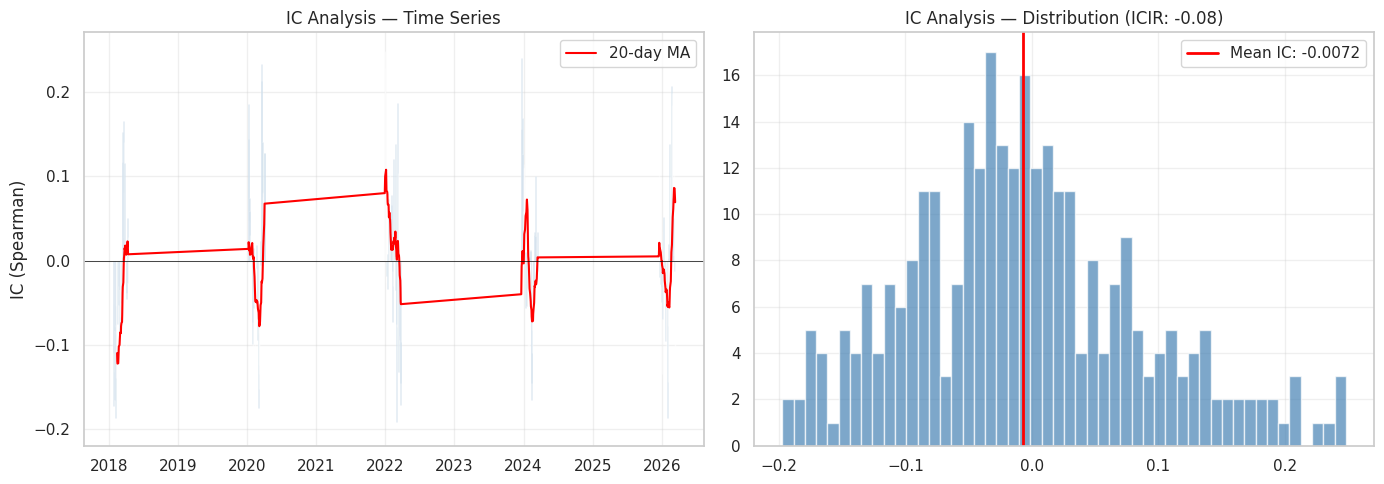

In [9]:
ic_series = calc_ic_series(predictions)
print(f"Mean IC:  {ic_series.mean():.4f}")
print(f"IC Std:   {ic_series.std():.4f}")
print(f"ICIR:     {ic_series.mean() / ic_series.std():.4f}")
print(f"IC > 0:   {(ic_series > 0).mean():.1%}")

plot_ic_analysis(ic_series)
plt.savefig("../output/equity_ic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 分层回测（Quantile Analysis）

按预测值分 5 组，如果模型有效，Q5（最高预测值）应该收益最高，Q1 最低，呈单调递增。

Annualized mean return by quintile:
quantile
1    36.77%
2    -5.56%
3   -45.25%
4    10.18%
5   -23.58%

Q5 - Q1 spread: -60.35% annualized


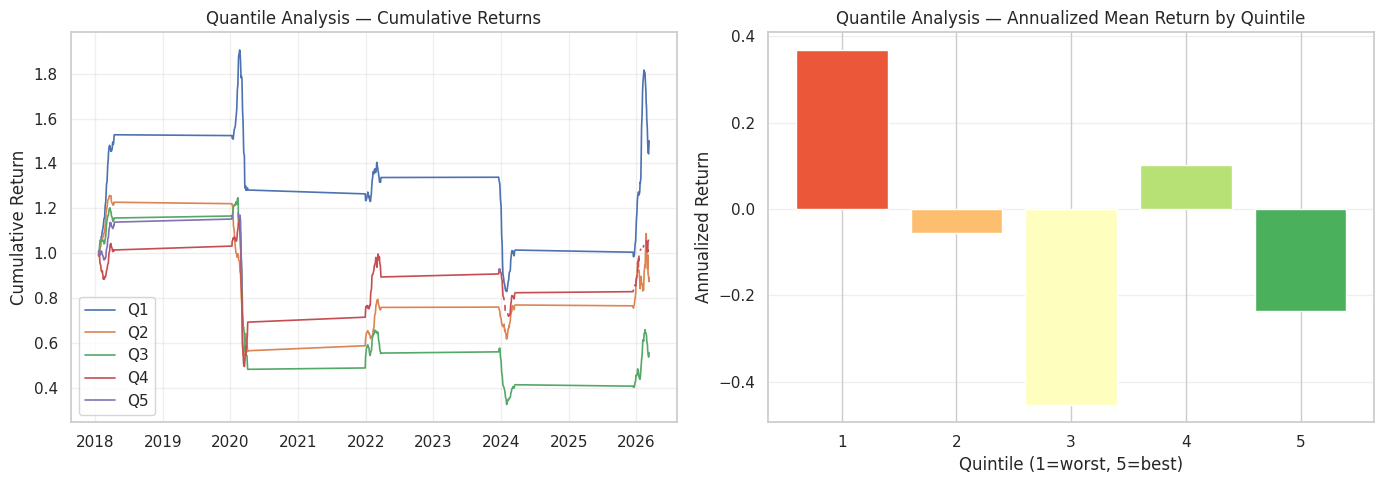

In [10]:
q_returns = quantile_analysis(predictions, n_groups=5)
print("Annualized mean return by quintile:")
print((q_returns.mean() * 252).to_string(float_format="{:.2%}".format))
print(f"\nQ5 - Q1 spread: {(q_returns[5].mean() - q_returns[1].mean()) * 252:.2%} annualized")

plot_quantile_returns(q_returns)
plt.savefig("../output/equity_quantile_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 回测 — Top 30 Long Only vs SPY

In [11]:
# Compute daily returns for backtest (raw returns, not residual)
daily_returns = compute_daily_returns(panel)

# Run backtest
bt_results = backtest_topN(
    predictions=predictions,
    returns=daily_returns,
    top_n=30,
    rebalance_days=10,
    cost_bps=10,
)

# Strategy metrics
print("=== Strategy (Top 30, 10-day rebalance, 10bps cost) ===")
strat_metrics = summary_metrics(bt_results["portfolio_return"])
print_metrics(strat_metrics)

# SPY benchmark metrics (same period)
spy_daily_ret = spy["close"].pct_change().reindex(bt_results.index).fillna(0)
print("\n=== SPY Benchmark ===")
spy_metrics = summary_metrics(spy_daily_ret)
print_metrics(spy_metrics)

print(f"\n=== Alpha ===")
print(f"  Annual excess return: {strat_metrics['annual_return'] - spy_metrics['annual_return']:.2%}")
print(f"  Average turnover per rebalance: {bt_results['turnover'][bt_results['turnover'] > 0].mean():.1%}")

=== Strategy (Top 30, 10-day rebalance, 10bps cost) ===
  Annual Return:      -32.49%
  Annual Volatility:   40.77%
  Sharpe Ratio:         -0.80
  Max Drawdown:       -52.79%
  Calmar Ratio:         -0.62
  Win Rate:            50.67%
  Trading Days:           300

=== SPY Benchmark ===
  Annual Return:      -22.61%
  Annual Volatility:   29.55%
  Sharpe Ratio:         -0.77
  Max Drawdown:       -37.61%
  Calmar Ratio:         -0.60
  Win Rate:            49.00%
  Trading Days:           300

=== Alpha ===
  Annual excess return: -9.88%
  Average turnover per rebalance: 67.3%


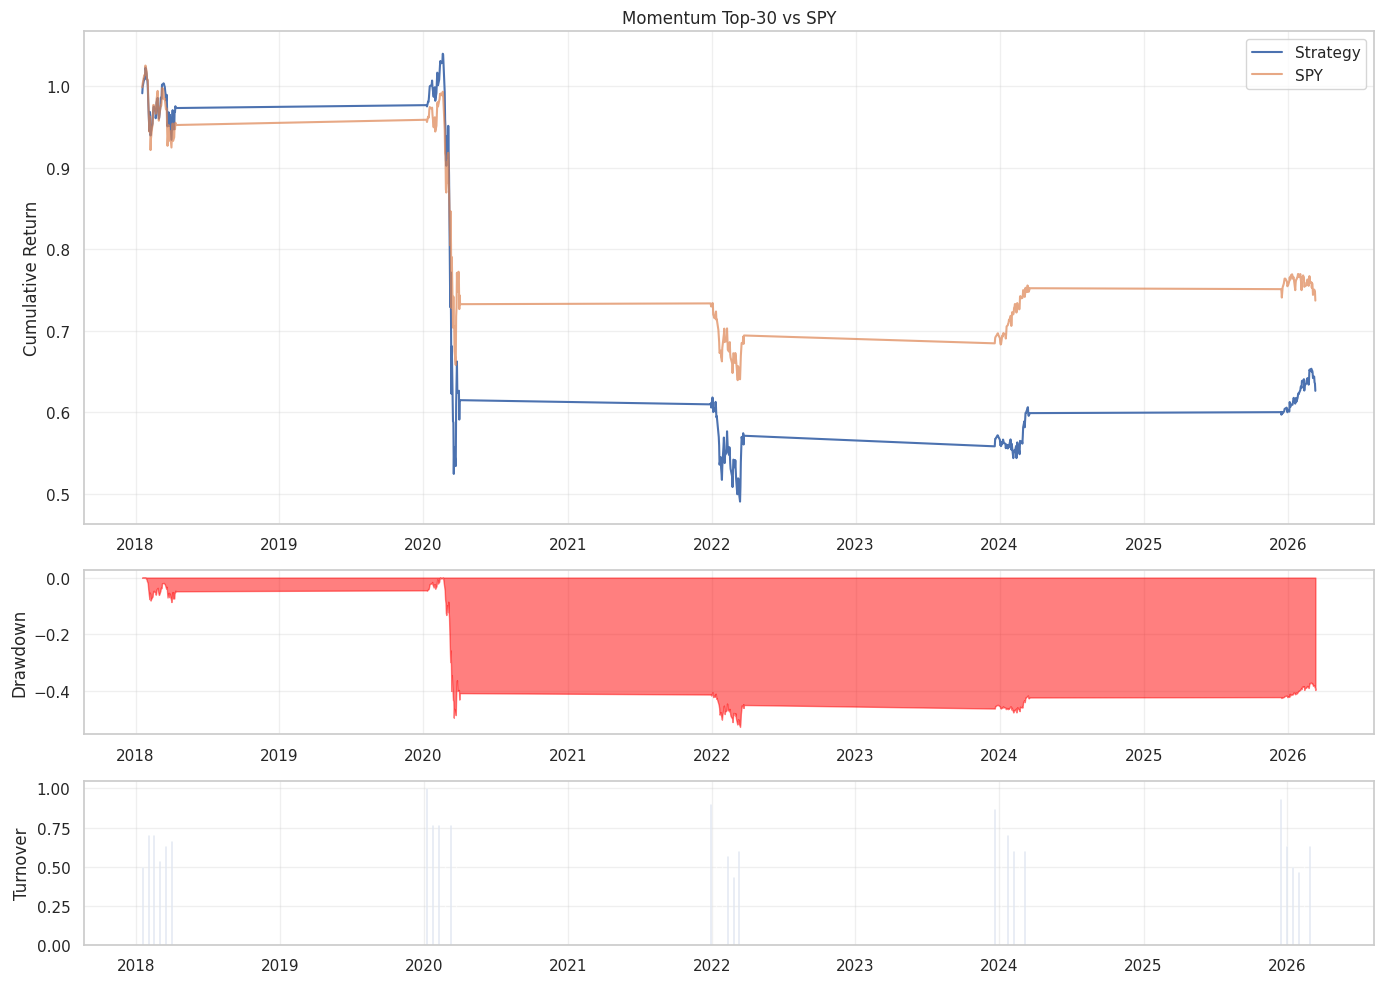

In [12]:
# Equity curve
plot_equity_curve(bt_results, spy_daily_ret, title="Momentum Top-30 vs SPY")
plt.savefig("../output/equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature Importance

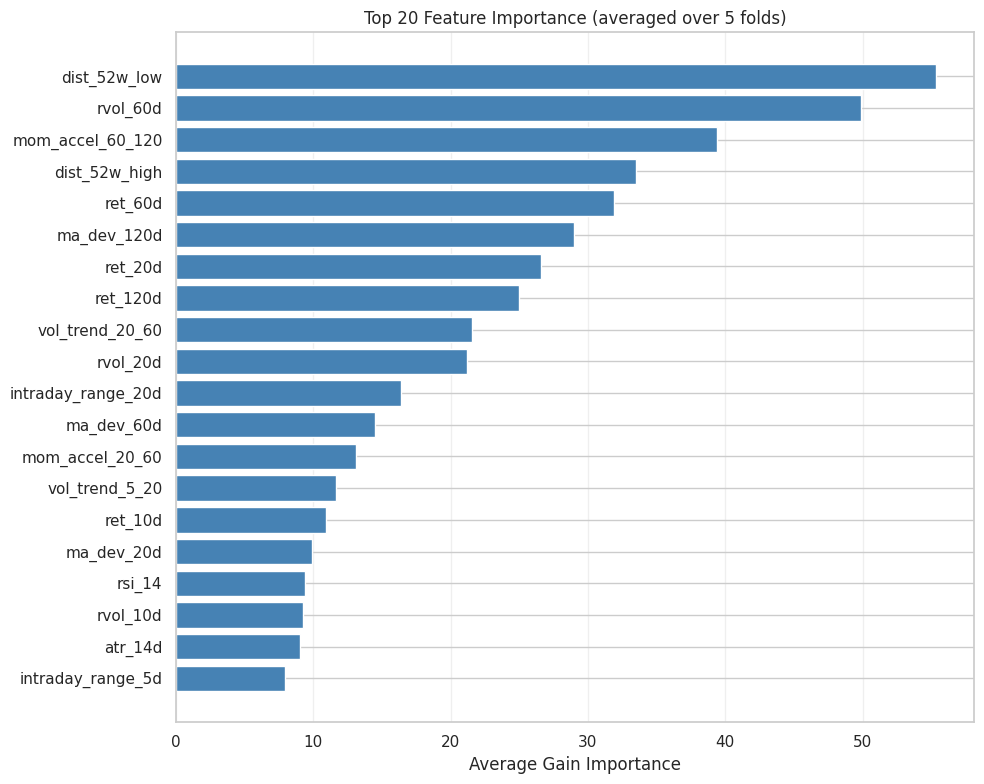

In [13]:
feature_names = features.columns.tolist()
plot_feature_importance(models, feature_names, top_n=20)
plt.savefig("../output/equity_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. 总结

**判断标准**:
- Mean IC > 0.02 且 ICIR > 0.5 → 信号有意义
- 分层回测 Q5 > Q4 > ... > Q1 → 模型有区分力
- 策略年化收益 > SPY 且扣费后为正 → pipeline 可用

**下一步改进方向**:
- 用 beta-adjusted 残差替代简单差值
- 加入历史成分股数据消除 survivorship bias
- 特征筛选（去掉 IC 接近 0 的特征）
- 调参（Optuna / 网格搜索）
- 加入财务因子（估值、盈利质量等）